# Management Risk Classification Project

## Project Overview

This notebook presents a complete Machine Learning experiment to classify project risk levels based on multiple organizational, technical, operational, and human-related factors.

### Objective
The main goal is to build and compare several classification models in order to select the best-performing model based on the **Recall** metric.

### Workflow Summary

1. Data Understanding  
   - Loaded and explored the dataset  
   - Checked structure, data types, and missing values  
   - Analyzed feature distributions  

2. Data Preprocessing  
   - Encoded categorical variables  
   - Split data into training and testing sets  
   - Applied feature scaling when required  

3. Model Training  
   The following models were trained and evaluated:
   - Logistic Regression  
   - Support Vector Machine (SVC)  
   - K-Nearest Neighbors  
   - Decision Tree  
   - Random Forest  
   - XGBoost  

4. Model Evaluation  
   - Models were evaluated using Recall score  
   - Classification reports were generated  
   - The best model was selected based on highest Recall  

5. Model Saving  
   - The selected best model was saved  
   - Test data was stored for reproducibility  

### Conclusion
Multiple classification algorithms were tested and compared.  
The final model was selected based on its ability to correctly detect risk classes (Recall), ensuring reliable risk prediction performance.


In [177]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [178]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ka66ledata/project-management-risk-raw")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'project-management-risk-raw' dataset.
Path to dataset files: /kaggle/input/project-management-risk-raw


In [179]:
print(os.listdir(path))

['project_risk_raw_dataset.csv']


In [180]:
first_data = pd.read_csv(path + "/project_risk_raw_dataset.csv")
data = first_data

In [181]:
print(data.shape)
data.head()

(4000, 51)


,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [182]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

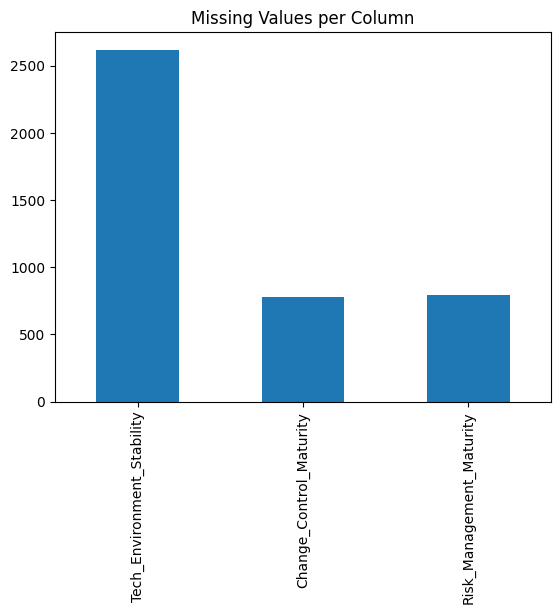

In [183]:
missing = data.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.show()

In [184]:
data = data.drop(['Project_ID', 'Tech_Environment_Stability'], axis=1)

In [185]:
data["Risk_Level"].value_counts()

,count
Risk_Level,
Medium,1396
High,1036
Low,806
Critical,762


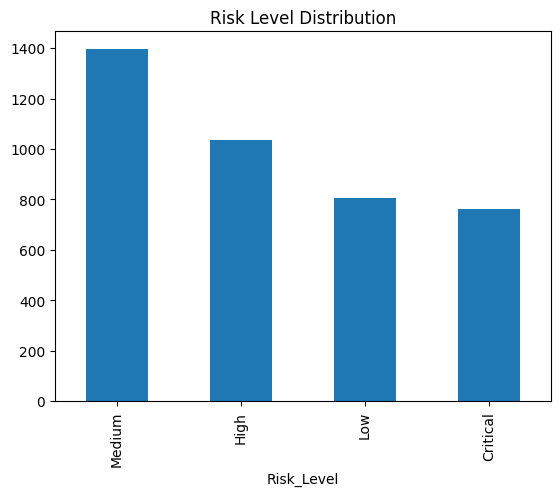

In [186]:
data["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

In [187]:
numeric_cols = data.select_dtypes(include = np.number).columns.tolist()
len(numeric_cols)

25

In [188]:
non_numeric_cols = data.select_dtypes(exclude = np.number).columns.tolist()
len(non_numeric_cols)

24

In [189]:
cat_cols_with_nulls = ['Change_Control_Maturity', 'Risk_Management_Maturity']

for col in cat_cols_with_nulls:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipython-input-1193283824.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [190]:
for col in non_numeric_cols:
  print(f"{col}: {data[col].unique()}")

Project_Type: ['Construction' 'Manufacturing' 'IT' 'R&D' 'Healthcare' 'Marketing']
Methodology_Used: ['Waterfall' 'Kanban' 'Agile' 'Scrum' 'Hybrid']
Team_Experience_Level: ['Senior' 'Mixed' 'Junior' 'Expert']
Project_Phase: ['Planning' 'Execution' 'Initiation' 'Closure' 'Monitoring']
Requirement_Stability: ['Moderate' 'Stable' 'Volatile']
Regulatory_Compliance_Level: ['Medium' 'High' 'Low' 'Critical']
Technology_Familiarity: ['Expert' 'Familiar' 'New']
Stakeholder_Engagement_Level: ['Medium' 'Excellent' 'Low' 'Poor' 'High']
Executive_Sponsorship: ['Moderate' 'Weak' 'Strong']
Funding_Source: ['Government' 'External' 'Internal' 'Mixed']
Priority_Level: ['Medium' 'Low' 'High' 'Critical']
Project_Manager_Experience: ['Mid-level PM' 'Certified PM' 'Senior PM' 'Junior PM']
Org_Process_Maturity: ['Managed' 'Optimizing' 'Ad-hoc' 'Defined']
Data_Security_Requirements: ['Medium' 'Low' 'Strict' 'High']
Key_Stakeholder_Availability: ['Limited' 'Excellent' 'Moderate' 'Good' 'Poor']
Contract_Type: [

In [191]:
ordinal_mappings = {
    'Team_Experience_Level': {'Junior': 0, 'Mixed': 1, 'Senior': 2, 'Expert': 3},
    'Project_Manager_Experience': {'Junior PM': 0, 'Mid-level PM': 1, 'Senior PM': 2, 'Certified PM': 3},
    'Client_Experience_Level': {'First-time': 0, 'Occasional': 1, 'Regular': 2, 'Strategic': 3},
    'Org_Process_Maturity': {'Ad-hoc': 0, 'Defined': 1, 'Managed': 2, 'Optimizing': 3},
    'Change_Control_Maturity': {'Basic': 0, 'Formal': 1, 'Advanced': 2},
    'Risk_Management_Maturity': {'Basic': 0, 'Formal': 1, 'Advanced': 2},
    'Priority_Level': {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3},
    'Regulatory_Compliance_Level': {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3},
    'Data_Security_Requirements': {'Low': 0, 'Medium': 1, 'High': 2, 'Strict': 3},
    'Stakeholder_Engagement_Level': {'Poor': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Excellent': 4},
    'Key_Stakeholder_Availability': {'Poor': 0, 'Limited': 1, 'Moderate': 2, 'Good': 3, 'Excellent': 4},
    'Documentation_Quality': {'Poor': 0, 'Basic': 1, 'Good': 2, 'Excellent': 3},
    'Executive_Sponsorship': {'Weak': 0, 'Moderate': 1, 'Strong': 2},
    'Technology_Familiarity': {'New': 0, 'Familiar': 1, 'Expert': 2},
    'Requirement_Stability': {'Volatile': 0, 'Moderate': 1, 'Stable': 2},
    'Industry_Volatility': {'Stable': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3},
    'Resource_Contention_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Risk_Level' : {'Low': 0, 'Medium': 1, 'High': 2, 'Critical' : 3}
}

nominal_columns = [
    'Project_Type',
    'Methodology_Used',
    'Project_Phase',
    'Funding_Source',
    'Contract_Type',
    'Team_Colocation'
]

In [192]:
for col in nominal_columns:
  print(data[col].value_counts(), "\n")

Project_Type
IT               1381
Construction      797
R&D               588
Manufacturing     418
Marketing         418
Healthcare        398
Name: count, dtype: int64 

Methodology_Used
Agile        1124
Scrum        1014
Waterfall     801
Kanban        575
Hybrid        486
Name: count, dtype: int64 

Project_Phase
Initiation    834
Planning      813
Closure       794
Execution     780
Monitoring    779
Name: count, dtype: int64 

Funding_Source
External      1655
Internal      1176
Mixed          752
Government     417
Name: count, dtype: int64 

Contract_Type
Time & Materials    1439
Fixed-Price         1320
Cost-Plus            622
Hybrid               619
Name: count, dtype: int64 

Team_Colocation
Hybrid                 1191
Fully Remote           1021
Partially Colocated     990
Fully Colocated         798
Name: count, dtype: int64 



In [193]:
for col, mapping in ordinal_mappings.items():
  if col in data.columns:
    data[col] = data[col].map(mapping)

In [194]:
data = pd.get_dummies(data, columns = nominal_columns, drop_first = True)
bool_cols = data.select_dtypes(include = 'bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [195]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 65 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Team_Size                            4000 non-null   int64  
 1   Project_Budget_USD                   4000 non-null   float64
 2   Estimated_Timeline_Months            4000 non-null   int64  
 3   Complexity_Score                     4000 non-null   float64
 4   Stakeholder_Count                    4000 non-null   int64  
 5   Team_Experience_Level                4000 non-null   int64  
 6   Past_Similar_Projects                4000 non-null   int64  
 7   External_Dependencies_Count          4000 non-null   int64  
 8   Change_Request_Frequency             4000 non-null   float64
 9   Requirement_Stability                4000 non-null   int64  
 10  Team_Turnover_Rate                   4000 non-null   float64
 11  Vendor_Reliability_Score      

In [196]:
missing = data.isnull().sum()
missing = missing[missing > 0]

print(len(missing))

0


In [197]:
data.duplicated().sum()

np.int64(0)

In [198]:
print(data.shape)
data.head(10)

(4000, 65)


,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Requirement_Stability,...,Project_Phase_Planning,Funding_Source_Government,Funding_Source_Internal,Funding_Source_Mixed,Contract_Type_Fixed-Price,Contract_Type_Hybrid,Contract_Type_Time & Materials,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated
0,32,1526276.55,32,9.70,16,2,3,3,1.05,1,...,1,1,0,0,0,0,1,0,0,0
1,2,390790.15,9,2.72,9,1,0,2,2.61,1,...,0,0,0,0,0,0,0,1,0,0
2,2,246674.76,6,2.04,7,1,1,0,0.83,2,...,0,0,1,0,0,0,0,0,1,0
3,12,1427830.63,17,7.54,16,1,0,5,2.42,1,...,0,0,0,1,0,1,0,0,1,0
4,24,1696746.64,24,6.68,17,0,0,2,0.16,2,...,0,1,0,0,0,0,0,0,0,1
5,13,1106456.85,18,7.11,12,1,0,5,0.68,1,...,0,0,0,1,0,0,1,0,1,0
6,12,1122048.59,21,10.00,11,2,3,5,2.76,1,...,0,0,0,1,1,0,0,0,0,0
7,9,1208078.86,15,4.53,9,1,3,4,0.28,1,...,0,0,0,1,0,0,1,0,0,1
8,37,1833354.63,35,9.49,13,1,0,4,3.61,1,...,0,0,0,0,1,0,0,0,0,0
9,41,2404494.18,28,5.09,18,2,2,2,0.83,1,...,0,0,0,1,0,0,1,0,0,0


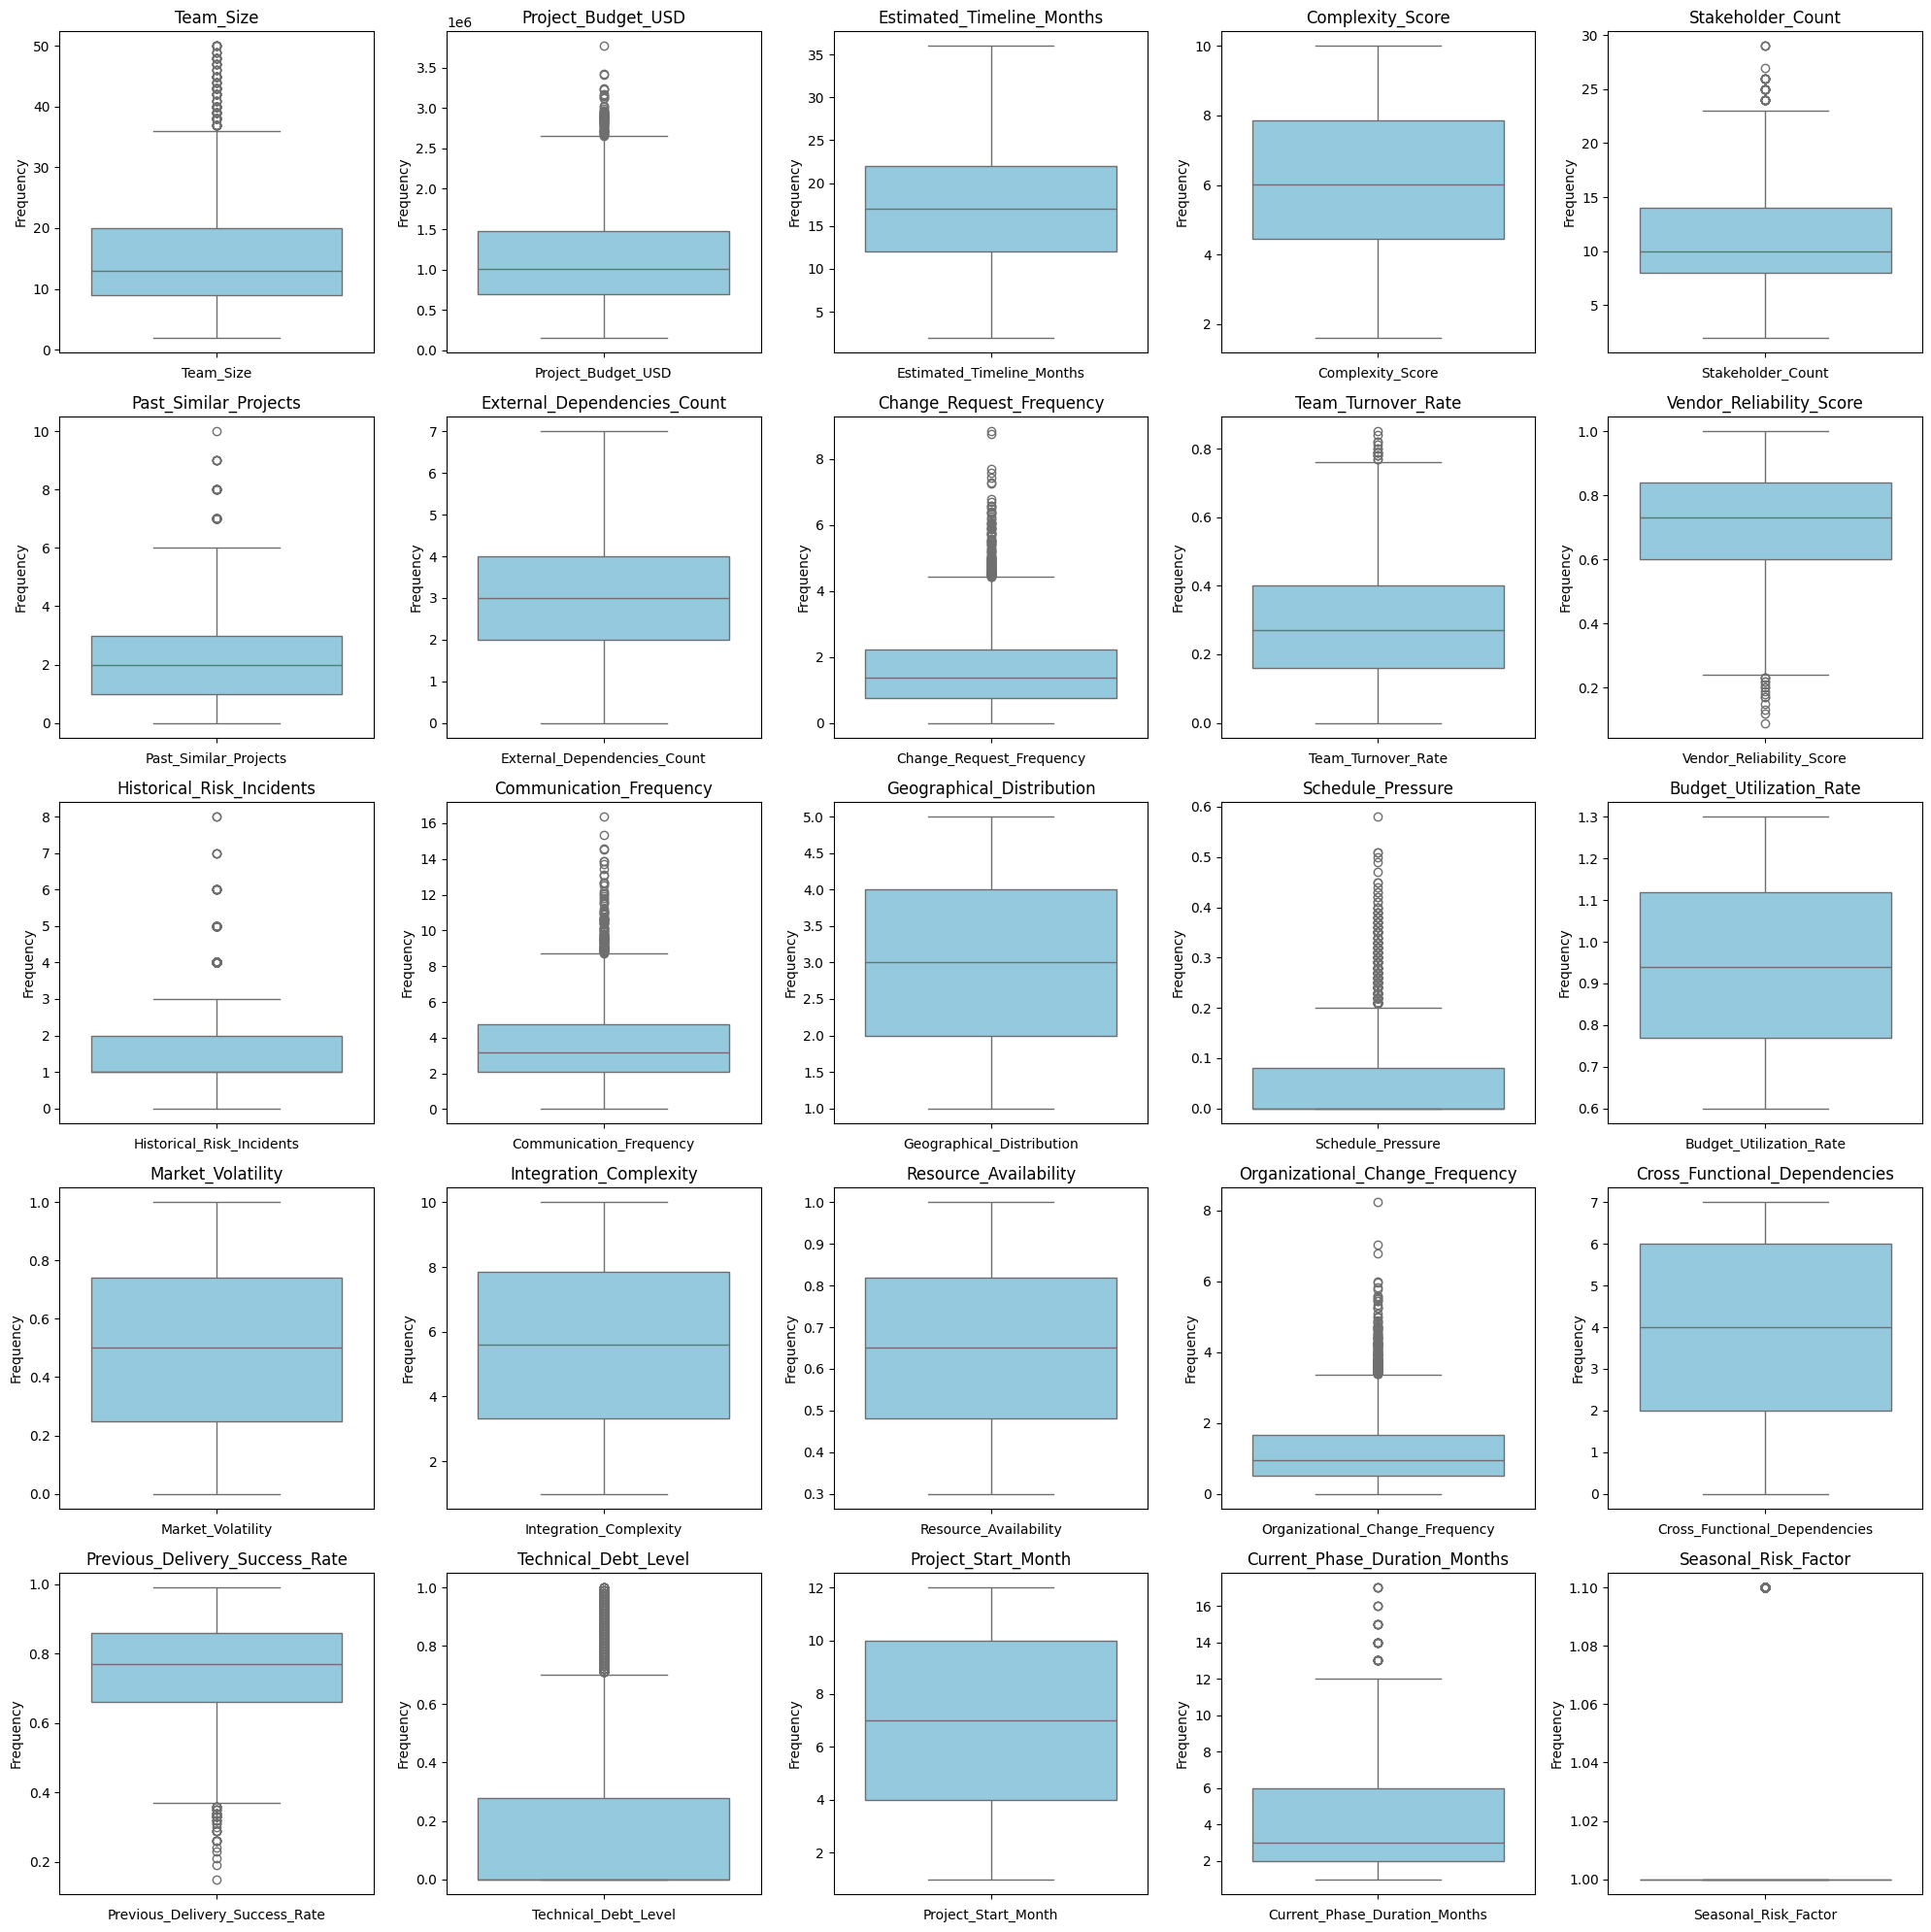

In [199]:
plt.figure(figsize=(20, 20))
for col in numeric_cols:
  plt.subplot(5,5,numeric_cols.index(col)+1)
  sns.boxplot(y = data[col], color = 'skyblue')
  plt.tight_layout()
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(col)
plt.show()

In [200]:
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

In [201]:
data.describe()

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Requirement_Stability,...,Project_Phase_Planning,Funding_Source_Government,Funding_Source_Internal,Funding_Source_Mixed,Contract_Type_Fixed-Price,Contract_Type_Hybrid,Contract_Type_Time & Materials,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated
count,4000.000000,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,15.181000,1.138455e+06,17.147750,6.192525,11.109500,1.413000,1.950500,3.127750,1.611294,1.102250,...,0.203250,0.104250,0.294000,0.188000,0.330000,0.154750,0.359750,0.255250,0.297750,0.247500
std,8.632257,5.774719e+05,6.926609,2.212538,4.361739,0.861752,1.683228,1.609216,1.082072,0.688414,...,0.402467,0.305623,0.455649,0.390761,0.470272,0.361711,0.479987,0.436056,0.457326,0.431614
min,2.000000,1.593555e+05,2.000000,1.620000,2.000000,0.000000,0.000000,0.000000,0.010000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,6.925329e+05,12.000000,4.460000,8.000000,1.000000,1.000000,2.000000,0.760000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,1.007472e+06,17.000000,6.015000,10.000000,1.000000,2.000000,3.000000,1.370000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,20.000000,1.475870e+06,22.000000,7.862500,14.000000,2.000000,3.000000,4.000000,2.230000,2.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,36.500000,2.650876e+06,36.000000,10.000000,23.000000,3.000000,6.000000,7.000000,4.435000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [202]:
X = data.drop('Risk_Level', axis=1)
y = data['Risk_Level']

In [203]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [204]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [205]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

best_model = None
best_recall = 0

lr = LogisticRegression(max_iter = 1000, random_state = 42)
svc = SVC(random_state = 42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state = 42)
rf = RandomForestClassifier(random_state = 42)
xgb = XGBClassifier(use_label_encoder = False, eval_metric = 'mlogloss', random_state = 42)


models = [lr, svc, knn, dt, rf, xgb]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    recall = recall_score(y_test, y_pred, average = 'weighted')

    if recall > best_recall:
        best_recall = recall
        best_model = model

    print(f"{model.__class__.__name__} Recall: {recall}")
    print(classification_report(y_test, y_pred))
    print("======================================================\n")

LogisticRegression Recall: 0.6475
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       163
           1       0.65      0.58      0.61       275
           2       0.58      0.57      0.57       215
           3       0.69      0.75      0.72       147

    accuracy                           0.65       800
   macro avg       0.65      0.67      0.66       800
weighted avg       0.65      0.65      0.65       800


SVC Recall: 0.63375
              precision    recall  f1-score   support

           0       0.77      0.65      0.70       163
           1       0.61      0.69      0.65       275
           2       0.54      0.54      0.54       215
           3       0.71      0.63      0.67       147

    accuracy                           0.63       800
   macro avg       0.66      0.63      0.64       800
weighted avg       0.64      0.63      0.63       800


KNeighborsClassifier Recall: 0.38
              precision    recall  f1-sc

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:29:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier Recall: 0.61625
              precision    recall  f1-score   support

           0       0.73      0.63      0.68       163
           1       0.55      0.66      0.60       275
           2       0.55      0.53      0.54       215
           3       0.79      0.65      0.71       147

    accuracy                           0.62       800
   macro avg       0.65      0.62      0.63       800
weighted avg       0.63      0.62      0.62       800




In [206]:
print("Best Model:", best_model.__class__.__name__)
print("Best Recall:", best_recall)

Best Model: LogisticRegression
Best Recall: 0.6475


In [207]:
import os
import joblib
import shutil
from google.colab import files

project_folder = "Data"

os.makedirs(f"{project_folder}", exist_ok=True)


In [208]:
joblib.dump(best_model, f"{project_folder}/best_model.pkl")


X_test = pd.DataFrame(X_test, columns=X.columns)
y_test = pd.DataFrame(y_test, columns=["target"])

first_data.to_csv(f"{project_folder}/project_risk_raw_dataset.csv", index=False)
data.to_csv(f"{project_folder}/processed_data.csv", index=False)
X_test.to_csv(f"{project_folder}/X_test.csv", index=False)
y_test.to_csv(f"{project_folder}/y_test.csv", index=False)


In [209]:
shutil.make_archive(project_folder, 'zip', project_folder)

files.download(f"{project_folder}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>